## **Dataset : Bike_store_Data**

---

## **Load and Explore Data**

In [1]:
# Import reqiured libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector as mysc

In [2]:
# Load Dataset.
bike_store_brand = pd.read_csv("brands.csv")
bike_store_category = pd.read_csv("categories.csv")
bike_store_customer = pd.read_csv("customers.csv")
bike_store_order_items = pd.read_csv("order_items.csv")
bike_store_order = pd.read_csv("orders.csv")
bike_store_product = pd.read_csv("products.csv")
bike_store_staff = pd.read_csv("staffs.csv")
bike_store_stores = pd.read_csv("stores.csv")

---

### **Available Information**
1) order contain order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id 
2) order_item contain  order_id,item_id,product_id,quantity,list_price,discount 
3) store contain store_id,store_name,phone,email,street,cit,state,zip_code
4) brand conatin brand_id,brand_name 
5) category contain category_id,category_name
6) product contain product_id,product_name,brand_id,category_id,model_year,list_price 
7) staff contain staff_id,first_name,last_name,email,phone,active,store_id,manager_id 
8) customer contain  customer_id,first_name,last_name,phone,email,street,city,state,zip_code 

---

## **Create files copy for analysis**

In [3]:
bsb = bike_store_brand.copy()
bsc = bike_store_category.copy()
bscu= bike_store_customer.copy()
bsoi = bike_store_order_items.copy()
bso = bike_store_order.copy()
bsp = bike_store_product.copy()
bsstaff = bike_store_staff.copy()
bsstore = bike_store_stores.copy()

---

## **Data cleaning**

**Ckeck missing value one by one**

In [4]:
bso.isnull().mean()*100

order_id          0.000000
customer_id       0.000000
order_status      0.000000
order_date        0.000000
required_date     0.000000
shipped_date     10.526316
store_id          0.000000
staff_id          0.000000
dtype: float64

- - There are shipped_date missing data available

In [5]:
bsoi.isnull().mean()*100

order_id      0.0
item_id       0.0
product_id    0.0
quantity      0.0
list_price    0.0
discount      0.0
dtype: float64

In [6]:
bsstore.isnull().mean()*100

store_id      0.0
store_name    0.0
phone         0.0
email         0.0
street        0.0
city          0.0
state         0.0
zip_code      0.0
dtype: float64

In [7]:
bsc.isnull().mean()*100

category_id      0.0
category_name    0.0
dtype: float64

In [8]:
bsb.isnull().mean()*100

brand_id      0.0
brand_name    0.0
dtype: float64

In [9]:
bsp.isnull().mean()*100

product_id      0.0
product_name    0.0
brand_id        0.0
category_id     0.0
model_year      0.0
list_price      0.0
dtype: float64

In [10]:
bsstore.isnull().mean()*100

store_id      0.0
store_name    0.0
phone         0.0
email         0.0
street        0.0
city          0.0
state         0.0
zip_code      0.0
dtype: float64

In [11]:
bsstaff.isnull().mean()*100

staff_id       0.0
first_name     0.0
last_name      0.0
email          0.0
phone          0.0
active         0.0
store_id       0.0
manager_id    10.0
dtype: float64

- - There are missing value in meneger_id.this column no need to change becuase all employees are not meneger

----

**Check information about datatype**

In [12]:
bso.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       1615 non-null   int64 
 1   customer_id    1615 non-null   int64 
 2   order_status   1615 non-null   int64 
 3   order_date     1615 non-null   object
 4   required_date  1615 non-null   object
 5   shipped_date   1445 non-null   object
 6   store_id       1615 non-null   int64 
 7   staff_id       1615 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 101.1+ KB


- - Hear date is object type  so need to change datatype in datetime

In [13]:
bso["order_date"] = pd.to_datetime(bso["order_date"])

In [14]:
bso["required_date"] = pd.to_datetime(bso["required_date"])

In [15]:

bso["shipped_date"] = pd.to_datetime(bso["shipped_date"])

In [16]:
bsoi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4722 entries, 0 to 4721
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    4722 non-null   int64  
 1   item_id     4722 non-null   int64  
 2   product_id  4722 non-null   int64  
 3   quantity    4722 non-null   int64  
 4   list_price  4722 non-null   float64
 5   discount    4722 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 221.5 KB


In [17]:
bsb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   brand_id    9 non-null      int64 
 1   brand_name  9 non-null      object
dtypes: int64(1), object(1)
memory usage: 276.0+ bytes


In [18]:
bsc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category_id    7 non-null      int64 
 1   category_name  7 non-null      object
dtypes: int64(1), object(1)
memory usage: 244.0+ bytes


In [19]:
bsp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    321 non-null    int64  
 1   product_name  321 non-null    object 
 2   brand_id      321 non-null    int64  
 3   category_id   321 non-null    int64  
 4   model_year    321 non-null    int64  
 5   list_price    321 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 15.2+ KB


In [20]:
bsstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    3 non-null      int64 
 1   store_name  3 non-null      object
 2   phone       3 non-null      object
 3   email       3 non-null      object
 4   street      3 non-null      object
 5   city        3 non-null      object
 6   state       3 non-null      object
 7   zip_code    3 non-null      int64 
dtypes: int64(2), object(6)
memory usage: 324.0+ bytes


In [21]:
bsstaff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   staff_id    10 non-null     int64  
 1   first_name  10 non-null     object 
 2   last_name   10 non-null     object 
 3   email       10 non-null     object 
 4   phone       10 non-null     object 
 5   active      10 non-null     int64  
 6   store_id    10 non-null     int64  
 7   manager_id  9 non-null      float64
dtypes: float64(1), int64(3), object(4)
memory usage: 772.0+ bytes


In [22]:
bscu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  1445 non-null   int64 
 1   first_name   1445 non-null   object
 2   last_name    1445 non-null   object
 3   phone        178 non-null    object
 4   email        1445 non-null   object
 5   street       1445 non-null   object
 6   city         1445 non-null   object
 7   state        1445 non-null   object
 8   zip_code     1445 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 101.7+ KB


- - Already clean data 

---

## **Exploratory Data Analysis (EDA)**

**Find totalorder , total sale qty , totalsale , avg sale**

In [23]:
TotalOrder = bsoi["order_id"].count()
TotalOrder

np.int64(4722)

In [24]:
TotalSaleQty = bsoi["quantity"].sum()
TotalSaleQty

np.int64(7078)

- - we have list price and discount so find out sale_price for extract total sale

In [25]:
bsoi["sale_price"] = (bsoi["list_price"] * (1 - bsoi["discount"]) )* bsoi["quantity"]

In [26]:
TotalSale = bsoi["sale_price"].sum()
TotalSale

np.float64(7689116.5576)

In [27]:
AvgSale = bsoi["sale_price"].mean()
AvgSale

np.float64(1628.3601350275308)

---

### **Que 1 :- Find out month wise sale**

- - Before find out month wise sales. we are need to merge order and order_item table and create new month column

In [28]:
orderitem_order = bsoi.merge(bso,how="inner",on="order_id")

In [29]:
orderitem_order["monthname"] = orderitem_order["order_date"].dt.month_name()

In [30]:
orderitem_order["month"] = orderitem_order["order_date"].dt.month

In [66]:
month_sale =orderitem_order.groupby(["month","monthname"])["sale_price"].sum()/100000
pd.options.display.float_format = '${:,.2f}M'.format 
month_sale = month_sale.reset_index()
month_sale

,month,monthname,sale_price
0,1,January,$8.82M
1,2,February,$6.70M
2,3,March,$8.54M
3,4,April,$12.12M
4,5,May,$4.74M
5,6,June,$5.90M
6,7,July,$4.41M
7,8,August,$5.25M
8,9,September,$5.75M
9,10,October,$5.26M


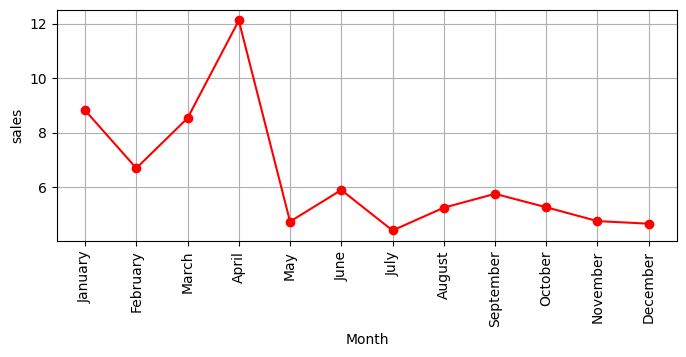

In [32]:
plt.figure(figsize=(8,3))
plt.plot(month_sale["monthname"],month_sale["sale_price"],marker = "o",color = "red")
plt.xticks(rotation=90) 
plt.xlabel("Month")
plt.ylabel("sales")
plt.grid()
plt.show()


- The line chart depicting sales variation by month can help identify seasonal trends. If sales peak during certain months, such as the summer or holiday season, the business can prepare for higher demand during these times and plan marketing campaigns accordingly.

---

### **Que 2 :- We want to total sale in category wise**

- In this case we need to merge category table with order and order_item

In [33]:
orderitem_order_product =orderitem_order.merge(bsp,how="inner",on="product_id")


In [34]:
orderitem_order_product_category = orderitem_order_product.merge(bsc,how="inner",on = "category_id")

In [35]:
result = orderitem_order_product_category.groupby("category_name")["sale_price"].sum()/100000
pd.options.display.float_format = '${:,.2f}M'.format 
result = result.reset_index()
result

,category_name,sale_price
0,Children Bicycles,$2.92M
1,Comfort Bicycles,$3.94M
2,Cruisers Bicycles,$9.95M
3,Cyclocross Bicycles,$7.11M
4,Electric Bikes,$9.17M
5,Mountain Bikes,$27.15M
6,Road Bikes,$16.65M


In [36]:
result = result.sort_values(by="sale_price")

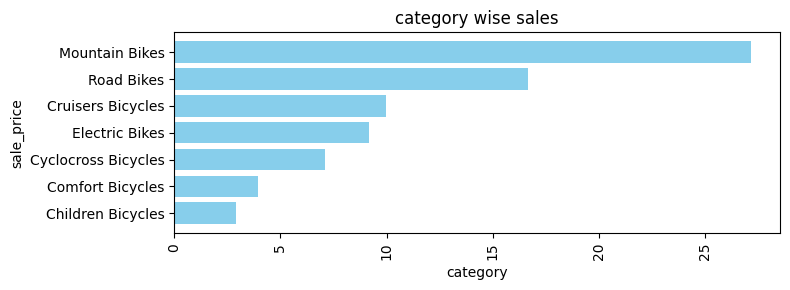

In [37]:
plt.figure(figsize=(8,3))
plt.barh(result["category_name"],result["sale_price"],color = "skyblue")
plt.xticks(rotation = 90)
plt.xlabel("category")
plt.ylabel("sale_price")
plt.title("category wise sales")
plt.tight_layout()

- The bar chart shows the total sales for each type of category over the year. This helps identify which types of category contribute most significantly to the revenue. For example, if "Mountain Bikes" category have the highest total sales, they are likely the most popular and should be a focus for promotions and inventory.

---

### **Que 2 :- Determine total sales in per for bike store**

In [38]:
orderitem_order_store = orderitem_order.merge(bsstore,how ="inner",on ="store_id")

In [39]:
per_result = orderitem_order_store.groupby("store_name")["sale_price"].sum()/100000
per_result = per_result.reset_index()
per_result

,store_name,sale_price
0,Baldwin Bikes,$52.16M
1,Rowlett Bikes,$8.68M
2,Santa Cruz Bikes,$16.06M


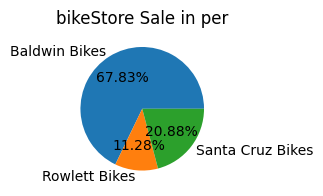

In [40]:
plt.figure(figsize=(3,3))
plt.pie(per_result["sale_price"],labels=per_result["store_name"],autopct='%0.2f%%')
plt.title("bikeStore Sale in per")
plt.tight_layout()
plt.show()

- The pie chart shows that Baldwin Bikes constitutes the largest share of store sales, accounting for approximately **67.83%** percent of total sales, significantly surpassing other store sales.

---

### **Que 4 :- Find out highest sold category , brand , product**

In [41]:
highSaleCategory = orderitem_order_product_category.groupby("category_name")["quantity"].sum().reset_index()
highSaleCategory.rename(columns={"category_name":"categoryName","quantity":"TotalOrder"},inplace=True)
highSaleCategory.sort_values(by = "TotalOrder",ascending=False).head(1)

,categoryName,TotalOrder
2,Cruisers Bicycles,2063


In [42]:
orderitem_order_product_brand=orderitem_order_product.merge(bsb,how= "inner",on="brand_id")

In [43]:
highSaleBrand = orderitem_order_product_brand.groupby("brand_name")["quantity"].sum().reset_index()
highSaleBrand = highSaleBrand.rename(columns={"brand_name":"brandName","quantity":"TotalOrder"})
highSaleBrand.sort_values(by = "TotalOrder",ascending=False).head(1)


,brandName,TotalOrder
0,Electra,2612


In [44]:
highSaleProduct = orderitem_order_product.groupby("product_name")["quantity"].sum().reset_index()
highSaleProduct = highSaleProduct.rename(columns={"producyt_name":"productName","quantity":"TotalOrder"})
highSaleProduct.sort_values(by = "TotalOrder",ascending=False).head(1)

,product_name,TotalOrder
6,Electra Cruiser 1 (24-Inch) - 2016,296


---

### **Que 5 :-What are the top 5  most popular product and bottom 5 product?**

In [45]:
top5product = orderitem_order_product.groupby("product_name")["sale_price"].sum()/100000
top5product =top5product.reset_index()
top5product =top5product.sort_values(by = "sale_price",ascending=False).head(5)
top5product

,product_name,sale_price
261,Trek Slash 8 27.5 - 2016,$5.56M
160,Trek Conduit+ - 2016,$3.89M
212,Trek Fuel EX 8 29 - 2016,$3.68M
146,Surly Straggler 650b - 2016,$2.27M
193,Trek Domane SLR 6 Disc - 2017,$2.12M


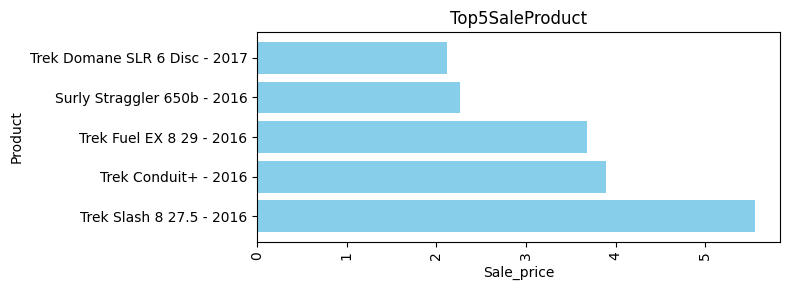

In [46]:
plt.figure(figsize=(8,3))
plt.barh(top5product["product_name"],top5product["sale_price"],color = "skyblue")
plt.xticks(rotation = 90)
plt.ylabel("Product")
plt.xlabel("Sale_price")
plt.title("Top5SaleProduct")
plt.tight_layout()

In [47]:
bottom5product = orderitem_order_product.groupby("product_name")["sale_price"].sum().reset_index()
bottom5product= bottom5product.sort_values(by = "sale_price",ascending=False).tail(5)

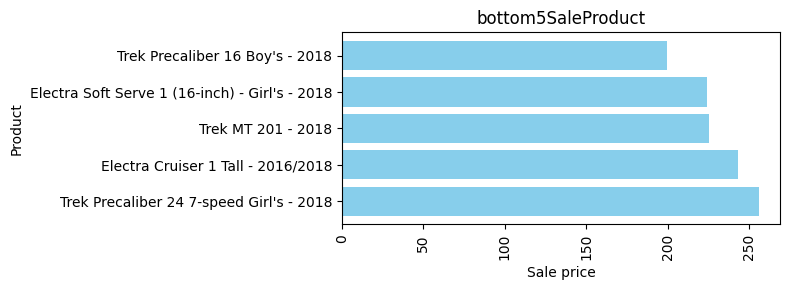

In [48]:
plt.figure(figsize=(8,3))
plt.barh(bottom5product["product_name"],bottom5product["sale_price"],color = "skyblue")
plt.xticks(rotation = 90)
plt.xlabel("Sale price")
plt.ylabel("Product")
plt.title("bottom5SaleProduct")
plt.tight_layout()

-  Identifies customer favorites and trending bikes in the market Reveals best-selling models for informed inventory decisions Informing targeted marketing and promotional strategies Enhancing customer satisfaction and sales growth Optimizing business performance through data-driven insights

---

### **Que 6 :- Find out top 5 sale brand in per?**

In [49]:
top5saleBrand = orderitem_order_product_brand.groupby("brand_name")["sale_price"].sum().reset_index()
top5saleBrand = top5saleBrand.rename(columns={"brand_name":"brandName","sale_price":"TotalSale"})
top5saleBrand = top5saleBrand.sort_values(by = "TotalSale",ascending=False).head(5)


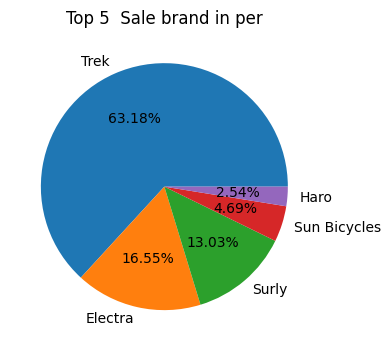

In [50]:
plt.figure(figsize=(4,4))
plt.pie(top5saleBrand["TotalSale"],labels=top5saleBrand["brandName"],autopct='%0.2f%%')
plt.title("Top 5  Sale brand in per")
plt.tight_layout()
plt.show()

---

### **Que 7 :-Analysis staff parfoamnce by sold product to each store?**

In [51]:
bsstaff["full_name"] = bsstaff["first_name"] +" " + bsstaff["last_name"]

In [52]:
orderitem_order_staff = orderitem_order.merge(bsstaff,how = "inner", on = "staff_id")

In [53]:
orderitem_order_staff_store = orderitem_order_staff.merge(bsstore,how = "inner", left_on = "store_id_x",right_on = "store_id")

In [54]:
Baldwin_bike_store = orderitem_order_staff_store[orderitem_order_staff_store["store_name"] == "Baldwin Bikes"]

In [55]:
mostActiveStaff_BBS = Baldwin_bike_store.groupby("full_name")["sale_price"].sum()/1000000
mostActiveStaff_BBS = mostActiveStaff_BBS.reset_index()
mostActiveStaff_BBS = mostActiveStaff_BBS.sort_values("sale_price", ascending=False).head(1)
mostActiveStaff_BBS

,full_name,sale_price
0,Marcelene Boyer,$2.62M


In [56]:
Santa_Cruz_bike_store = orderitem_order_staff_store[orderitem_order_staff_store["store_name"] == "Santa Cruz Bikes"]

In [57]:
mostActiveStaff_SCS = Santa_Cruz_bike_store.groupby("full_name")["sale_price"].sum()/1000
mostActiveStaff_SCS = mostActiveStaff_SCS.reset_index()
mostActiveStaff_SCS = mostActiveStaff_SCS.sort_values("sale_price", ascending=False).head(1)
mostActiveStaff_SCS

,full_name,sale_price
0,Genna Serrano,$853.29M


- You can find all other store staff parfomance using this code

---

### **Que 8 :-Find out total customer to each store?**

In [58]:
bscu["Customer_full_name"] = bscu["first_name"] + " " +bscu["last_name"]

In [59]:
orderitem_order_store_customer = orderitem_order_store.merge(bscu, how = "inner", on= "customer_id")

In [60]:
Baldwing_B_S = orderitem_order_store_customer[orderitem_order_staff_store["store_name"] == "Baldwin Bikes"]


In [61]:
Baldwing_B_S_total_customer = Baldwing_B_S["customer_id"].nunique()
Baldwing_B_S_total_customer

1019

In [62]:
Santa_c_B_S = orderitem_order_store_customer[orderitem_order_store_customer["store_name"] == "Santa Cruz Bikes"]

In [63]:
Santa_c_B_S_total_customer = Santa_c_B_S["customer_id"].nunique()
Santa_c_B_S_total_customer

284

---

### **Que 9 :- Find out top 5 customer to each store?**

In [64]:
top_5_customer_baldwin_store = Baldwing_B_S.groupby("Customer_full_name")["sale_price"].sum()/10000
top_5_customer_baldwin_store = top_5_customer_baldwin_store.reset_index()
top_5_customer_baldwin_store = top_5_customer_baldwin_store.sort_values(by = "sale_price",ascending=False).head(5)
top_5_customer_baldwin_store

,Customer_full_name,sale_price
836,Sharyn Hopkins,$3.48M
734,Pamelia Newman,$3.36M
2,Abby Gamble,$3.28M
618,Lyndsey Bean,$3.27M
310,Emmitt Sanchez,$3.19M


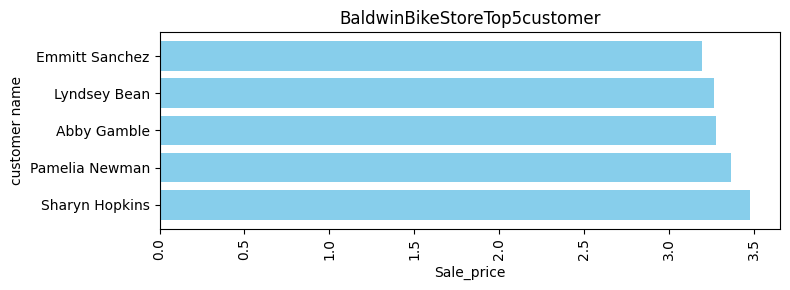

In [65]:
plt.figure(figsize=(8,3))
plt.barh(top_5_customer_baldwin_store["Customer_full_name"],top_5_customer_baldwin_store["sale_price"],color = "skyblue")
plt.xticks(rotation = 90)
plt.ylabel("customer name")
plt.xlabel("Sale_price")
plt.title("BaldwinBikeStoreTop5customer")
plt.tight_layout()

- You can find other store top 5 customer using this code

-The bar chart indicating the top 5 customers warrants exclusive discounts and offers to foster loyalty and increase store sales